In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Image
from IPython.display import display
import PIL.Image
import easyocr
import re
import statistics
import math
import pandas as pd
from itertools import zip_longest
from collections import defaultdict
import genanki
import random

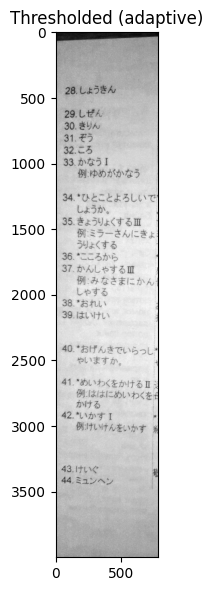

In [4]:
img_read_kana = cv2.imread("dictSample2.jpg", cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=[18,15])
kernel = np.ones((5,5), np.uint8)
proc_kana = cv2.dilate(img_read_kana, kernel, iterations=1)
plt.subplot(224); plt.imshow(proc_kana,  cmap="gray");  plt.title("Thresholded (adaptive)");

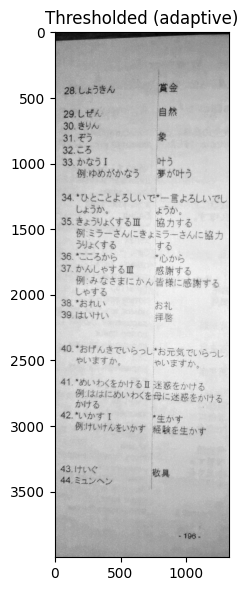

In [5]:
img_read_kanji = cv2.imread("dictSample3.jpg", cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=[18,15])
#img_resized = cv2.resize(img_read_kanji, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
#clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
#proc_kanji = clahe.apply(img_resized)
kernel = np.ones((5,5), np.uint8)
proc_kanji = cv2.dilate(img_read_kanji, kernel, iterations=1)
plt.subplot(224); plt.imshow(proc_kanji,  cmap="gray");  plt.title("Thresholded (adaptive)");

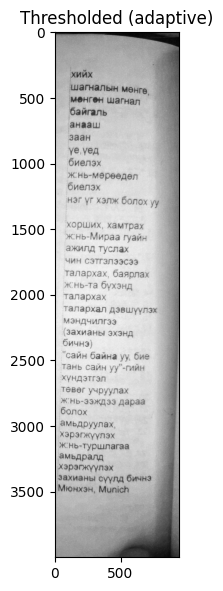

In [6]:
img_read_mn = cv2.imread("dictSample4.jpg", cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=[18,15])
kernel = np.ones((5,5), np.uint8)
proc_mn = cv2.dilate(img_read_mn, kernel, iterations=1)
plt.subplot(224); plt.imshow(proc_mn,  cmap="gray");  plt.title("Thresholded (adaptive)");

In [7]:
readerJa = easyocr.Reader(['ja', "en"])
readerMn = easyocr.Reader(['mn'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [8]:
result_kana = readerJa.readtext(proc_kana)
result_kanji = readerJa.readtext(proc_kanji)
result_mn = readerMn.readtext(proc_mn)

/home/jc/Documents/learnAI/jpMonDict/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [9]:
print("kana test")
for (bbox, text, prob) in result_kana:
    print(f'Text: {text}, Probability: {prob}')

print("kanji test")
for (bbox, text, prob) in result_kanji:
    print(f'Text: {text}, Probability: {prob}')
    
print("mon text")
for (bbox, text, prob) in result_mn:
    print(f'Text: {text}, Probability: {prob}')

kana test
Text: 28.しょうきん, Probability: 0.9874725203681037
Text: 29.しぜん, Probability: 0.977978910914341
Text: 30.きりん, Probability: 0.9996094302723999
Text: 31.ぞう, Probability: 0.8827299958353484
Text: 32,ころ, Probability: 0.7247476898256582
Text: 33 かなう】, Probability: 0.33243246004575394
Text: 例ゆめがかなう, Probability: 0.9985475212374046
Text: 34*ひとことよろしいで, Probability: 0.8133543389019469
Text: しょうか, Probability: 0.9997389912605286
Text: 35.きょうりょくする皿, Probability: 0.9400645752528246
Text: 例ミラーさんにきよ, Probability: 0.9660223310034319
Text: うりょくする, Probability: 0.9994822991201155
Text: 36*こころから, Probability: 0.8894256491486682
Text: 37.かんしやする皿, Probability: 0.878317613980388
Text: 例みなさまにかん, Probability: 0.9979357338591214
Text: しゃする, Probability: 0.5599094033241272
Text: 38 *おれい, Probability: 0.7604996605681038
Text: 39.はいけい, Probability: 0.8985011591556156
Text: 40., Probability: 0.9115125181323405
Text: *おげんきでいらつし, Probability: 0.7103557250549659
Text: やいますか_, Probability: 0.5426142800810683
T

In [10]:
# each result is ([bbox], text, confidence)
# bbox is [[x1,y1],[x2,y1],[x2,y2],[x1,y2]]

# get y center of each result
def get_y_center(bbox):
    return (bbox[0][1] + bbox[2][1]) / 2
def get_height(bbox):
    return bbox[2][1] - bbox[0][1]

defCols = [result_kana, result_kanji, result_mn]

In [11]:
def find_entry_num(curr_y, kana_anchors, tolerance=50):
    above = [(num, y) for num, y in kana_anchors if y - tolerance <= curr_y]
    if above:
        return max(above, key=lambda x: x[1])[0]
    return None

In [45]:
finalCol = {"kana": [], "kanji": [], "mon": []}
filters = {
    "kana":  r'[^\u3040-\u309F\u30A0-\u30FF\d\例]',
    "kanji": r'[^\u3040-\u309F\u30A0-\u30FF\u4E00-\u9FFF]',
    "mon":   r'[^\u0400-\u04FF]',
}
kana_anchors = []
keys = list(finalCol.keys())
for i, wordDef in enumerate(defCols):
    # sort by y position
    results_sorted = sorted(wordDef, key=lambda r: get_y_center(r[0]))
    
    # group into lines by y proximity
    lines = []
    current_line = [results_sorted[0]]
    threshold = 40  # tune this — pixel distance to consider same line
    
    for result in results_sorted[1:]:
        if abs(get_y_center(result[0]) - get_y_center(current_line[-1][0])) < threshold:
            current_line.append(result)
        else:
            lines.append(current_line)
            current_line = [result]
    lines.append(current_line)
    
    # print each line
    for j,line in enumerate(lines):
        avg_height = sum(get_height(line[0][0]) for line in lines) / len(lines)
        line_text = " ".join([r[1] for r in sorted(line, key=lambda r: r[0][0][0])])
        # replace non language text with space
        cleaned = re.sub(filters[keys[i]], " ", line_text).lower()
        # clean up result to be single spaces
        cleaned = re.sub(r' +', ' ', cleaned.strip())
        curr_y = get_y_center(line[0][0])

        if (keys[i] == "kana"):
            if (re.match(r'^\d+', cleaned)):
                entry_num = int(re.match(r'^\d+', cleaned).group())
                # remove number from cleaned
                cleaned = re.sub(r'\d+', '', cleaned).strip()
                kana_anchors.append((entry_num, get_y_center(line[0][0])))
        else:
            entry_num = find_entry_num(curr_y, kana_anchors)
        finalCol[keys[i]].append({"num": entry_num, "text": cleaned})

In [51]:
for i, line in enumerate(finalCol["mon"]):
   finalCol["mon"][i]["text"] = re.sub(r'ж\s*н\s*ь', 'ж:нь', line["text"])

In [52]:
# remove any unmatched definition
for key in keys:
    finalCol[key] = [x for x in finalCol[key] if x["num"] is not None and x["text"].strip() != '']

In [53]:
kana_by_num = defaultdict(list)
for item in finalCol["kana"]:
    kana_by_num[item["num"]].append(item["text"])

kanji_by_num = defaultdict(list)
for item in finalCol["kanji"]:
    kanji_by_num[item["num"]].append(item)

for num in kanji_by_num:
    for kanji_item, kana_text in zip(kanji_by_num[num], kana_by_num[num]):
        kanji_item["text"] = kanji_item["text"].removeprefix(kana_text).strip()

In [54]:
finalCol["mon"]

[{'num': 28, 'text': 'шагналын мөнгө'},
 {'num': 28, 'text': 'мөнгөн шагнал'},
 {'num': 29, 'text': 'байгаль'},
 {'num': 30, 'text': 'анааш'},
 {'num': 31, 'text': 'заан'},
 {'num': 32, 'text': 'үе үед'},
 {'num': 33, 'text': 'биелэх'},
 {'num': 33, 'text': 'ж:нь мөрөөдөл'},
 {'num': 33, 'text': 'биелэх'},
 {'num': 34, 'text': 'нэг үг хэлж болох уу'},
 {'num': 35, 'text': 'хорших хамтрах'},
 {'num': 35, 'text': 'ж:нь мираа гуайн'},
 {'num': 35, 'text': 'ажилд туслах'},
 {'num': 36, 'text': 'чин сэтгэлээсээ'},
 {'num': 37, 'text': 'талархах баярлах'},
 {'num': 37, 'text': 'ж:нь та бүхэнд'},
 {'num': 38, 'text': 'талархах'},
 {'num': 39, 'text': 'талархал дэвшүүлэх'},
 {'num': 39, 'text': 'мэндчилгээ'},
 {'num': 39, 'text': 'захианы эхэнд'},
 {'num': 40, 'text': 'бичнэ'},
 {'num': 40, 'text': 'сайн байна уу бие'},
 {'num': 40, 'text': 'тань сайн уу гийн'},
 {'num': 41, 'text': 'хүндэтгэл'},
 {'num': 41, 'text': 'төвөг учруулах'},
 {'num': 41, 'text': 'ж:нь ээждээ дараа'},
 {'num': 42, 't

In [55]:
processedDict = {"kana": [], "kanji": [], "mon": []}
for key in keys:
    df = pd.DataFrame(finalCol[key])
    grouped = df.groupby("num")["text"].apply("\n".join).tolist()
    processedDict[key].extend(grouped)

In [56]:
for key in keys:
    print(key)
    for entry in processedDict[key]:
        print(entry)
        print("----")

kana
しょうきん
----
しぜん
----
きりん
----
ぞう
----
ころ
----
かなう
例ゆめがかなう
----
ひとことよろしいで
しょうか
----
きょうりょくする
例ミラーさんにきよ
うりょくする
----
こころから
----
かんしやする
例みなさまにかん
しゃする
----
おれい
----
はいけい
----
おげんきでいらつし
やいますか
----
めいわくをかける
例ははにめいわくを
かける
----
いかす
けいけんをいかす
----
けいく
----
ミユンヘン
----
kanji
覚金
----
自然
----
象
----
叶う
夢が叶う
----
一言よろしいでし
ようか
----
皿 協力する
例ミラーさんにきょミラーさんに協力
する
----
心から
----
皿 感謝する
音様に感謝する
しやする
----
お礼
----
拝啓
----
おげんきでいらっし お元気でいらっし

----
迷惑をかける
母に迷惑をかける
----
生かす
例けいけんをいかす 経験を生かす
----
敬具
----
mon
шагналын мөнгө
мөнгөн шагнал
----
байгаль
----
анааш
----
заан
----
үе үед
----
биелэх
ж:нь мөрөөдөл
биелэх
----
нэг үг хэлж болох уу
----
хорших хамтрах
ж:нь мираа гуайн
ажилд туслах
----
чин сэтгэлээсээ
----
талархах баярлах
ж:нь та бүхэнд
----
талархах
----
талархал дэвшүүлэх
мэндчилгээ
захианы эхэнд
----
бичнэ
сайн байна уу бие
тань сайн уу гийн
----
хүндэтгэл
төвөг учруулах
ж:нь ээждээ дараа
----
болох
амьдруулах
хэрэгжүүлэх
ж:нь туршлагаа
амьдралд
----
хэрэгжүүлэх
----
захианы сүүлд бичнэ
мюнхэн мшпс


In [57]:
model = genanki.Model(
    random.randrange(1 << 30, 1 << 31),  # random unique id
    'Japanese-Mongolian',
    fields=[
        {'name': 'Kana'},
        {'name': 'Kanji'},
        {'name': 'Mongolian'},
    ],
    templates=[{
        'name': 'Card',
        'qfmt': '<span style="font-size: 30px; ">{{Kanji}}<span><br><br><span style="font-size: 30px; ">{{Kana}}<span>',   # front
        'afmt': '{{FrontSide}}<hr id=answer><span style="font-size: 35px; ">{{Mongolian}}</span>',  # back
    }],
    css='''
.card {
    font-family: arial;
    font-size: 40px;
    text-align: center;
    color: black;
    background-color: white;
    white-space: pre-wrap;
}
'''
)

# create deck
deck = genanki.Deck(
    random.randrange(1 << 30, 1 << 31),  # random unique id
    'Japanese-Mongolian Dictionary'
)

# add notes
for kana, kanji, mon in zip(processedDict["kana"], processedDict["kanji"], processedDict["mon"]):
    note = genanki.Note(
        model=model,
        fields=[kana, kanji, mon]
    )
    deck.add_note(note)

# export
genanki.Package(deck).write_to_file('japanese_mongolian.apkg')